In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("CarPrice_Assignment.csv")
print(data.head())
print(data.info())

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

In [3]:
data = data.drop(['CarName', 'car_ID'], axis=1)
data = pd.get_dummies(data, drop_first=True)

In [4]:
X = data.drop('price', axis=1)
y = data['price']

In [5]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(np.array(y).reshape(-1, 1))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3)

In [8]:
sgd_model.fit(X_train, y_train)

C:\ProgramData\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGDRegressor()

In [9]:
y_pred = sgd_model.predict(X_test)

In [10]:
mse=mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae=mean_absolute_error(y_test,y_pred)

In [11]:
print("Name:Anisha A")
print("Reg. No:212225220009")
print("MSE (Mean Squared Error):", mse)
print("R-squared Score:", r2)
print("MAE (Mean Absolute Error):",mae)

Name:Anisha A
Reg. No:212225220009
MSE (Mean Squared Error): 0.21741172161591904
R-squared Score: 0.8250923495106819
MAE (Mean Absolute Error): 0.32183511742208554


In [12]:
print("Model Coefficients:")
print("Coefficients:", sgd_model.coef_)
print("Intercept:", sgd_model.intercept_)

Model Coefficients:
Coefficients: [ 0.03435466  0.10702948  0.02043361  0.17576425  0.02121904  0.16620927
  0.27939414 -0.01807835 -0.08150746  0.00408911  0.10618486  0.0350787
 -0.04398518 -0.04777035 -0.02011854  0.01871489  0.01650247 -0.01664767
 -0.08755263 -0.01121325 -0.09282691 -0.03165971  0.06537415  0.21136393
  0.01608153 -0.09972019  0.07239943 -0.01664679  0.00302295  0.00910135
 -0.03041446 -0.1422483  -0.06894687  0.0008732  -0.02232486  0.00910135
 -0.00435269 -0.01497646  0.02011854 -0.01764783 -0.03169625 -0.03919005
 -0.01692618]
Intercept: [-0.01247537]


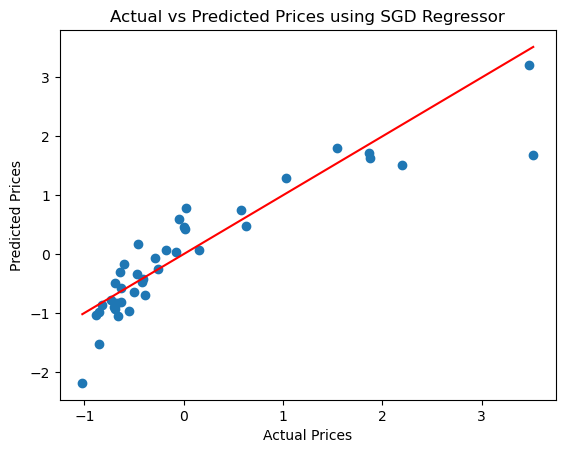

In [13]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices using SGD Regressor")
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)],color='red')
plt.show()